# MGMT298D: Science and Strategy of AI
## Week 4: Reinforcement Learning

## *Application: E-commerce Price Optimization*

---

## Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# THE "TRUE" ENVIRONMENT (pretend you don't know this!)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
PRICES = [5, 10, 15, 20, 25]
TRUE_CONVERSION_RATES = [0.50, 0.35, 0.22, 0.12, 0.05]  # Higher price → fewer buyers

def simulate_sale(price_index):
    """Simulate one customer. Returns revenue (price if they buy, 0 if not)."""
    bought = np.random.random() < TRUE_CONVERSION_RATES[price_index]
    return PRICES[price_index] if bought else 0

#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# BANDIT ALGORITHMS
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
def run_bandit(strategy, epsilon, n_customers, ucb_confidence=2.0):
    """Run a bandit algorithm and return results."""
    counts = [0, 0, 0, 0, 0]      # How many times we tried each price
    total_rewards = [0, 0, 0, 0, 0]  # Total revenue from each price
    history = []                   # Track cumulative revenue over time
    cumulative = 0
    
    for t in range(n_customers):
        # Choose a price
        if strategy == 'random':
            choice = np.random.randint(5)
        elif strategy == 'ucb':
            if min(counts) == 0:  # Try each price once first
                choice = counts.index(0)
            else:
                # UCB: pick price with highest (average + uncertainty bonus)
                ucb_scores = []
                for i in range(5):
                    avg = total_rewards[i] / counts[i]
                    bonus = ucb_confidence * np.sqrt(np.log(t + 1) / counts[i])
                    ucb_scores.append(avg + bonus)
                choice = ucb_scores.index(max(ucb_scores))
        elif strategy == 'epsilon-greedy':
            if min(counts) == 0:
                choice = counts.index(0)
            elif np.random.random() < epsilon:
                choice = np.random.randint(5)  # Explore
            else:
                avgs = [total_rewards[i]/counts[i] for i in range(5)]
                choice = avgs.index(max(avgs))  # Exploit
        
        # Get result
        revenue = simulate_sale(choice)
        counts[choice] += 1
        total_rewards[choice] += revenue
        cumulative += revenue
        history.append(cumulative)
    
    return history, counts, total_rewards

#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# Q-LEARNING ENVIRONMENT AND ALGORITHM
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
class PricingGame:
    """Simple inventory-based pricing game."""
    def __init__(self, inventory=20, time_limit=20):
        self.start_inventory = inventory
        self.time_limit = time_limit
        self.reset()
    
    def reset(self):
        self.inventory = self.start_inventory
        self.time_left = self.time_limit
        return self.get_state()
    
    def get_state(self):
        # Simplified state: (inventory_level, time_level)
        inv = 'high' if self.inventory > 10 else 'low'
        time = 'early' if self.time_left > 10 else 'late'
        return (inv, time)
    
    def step(self, price_index):
        if self.time_left <= 0 or self.inventory <= 0:
            return self.get_state(), 0, True
        
        # Conversion rate increases as deadline approaches (urgency!)
        base_rate = TRUE_CONVERSION_RATES[price_index]
        urgency = 1 + 0.5 * (1 - self.time_left / self.time_limit)
        rate = min(0.9, base_rate * urgency)
        
        sold = np.random.random() < rate
        revenue = PRICES[price_index] if sold else 0
        
        if sold:
            self.inventory -= 1
        self.time_left -= 1
        
        done = self.time_left <= 0 or self.inventory <= 0
        return self.get_state(), revenue, done

def run_qlearning(learning_rate, discount, epsilon, n_episodes):
    """Train a Q-learning agent and return results."""
    # Q-table: for each state, store expected value of each price
    Q = {
        ('high', 'early'): [0, 0, 0, 0, 0],
        ('high', 'late'):  [0, 0, 0, 0, 0],
        ('low', 'early'):  [0, 0, 0, 0, 0],
        ('low', 'late'):   [0, 0, 0, 0, 0],
    }
    
    game = PricingGame()
    episode_revenues = []
    
    for episode in range(n_episodes):
        state = game.reset()
        total_revenue = 0
        
        while True:
            # Choose action (epsilon-greedy)
            if np.random.random() < epsilon:
                action = np.random.randint(5)
            else:
                action = Q[state].index(max(Q[state]))
            
            # Take action
            next_state, revenue, done = game.step(action)
            total_revenue += revenue
            
            # Q-learning update
            old_value = Q[state][action]
            if done:
                target = revenue
            else:
                target = revenue + discount * max(Q[next_state])
            Q[state][action] = old_value + learning_rate * (target - old_value)
            
            state = next_state
            if done:
                break
        
        episode_revenues.append(total_revenue)
    
    return episode_revenues, Q

---

# Part 1: Multi-Armed Bandits


**Three strategies:**
- **Random**: Just guess
- **ε-Greedy**: Usually pick the best-so-far, but explore randomly ε% of the time
- **UCB (Upper Confidence Bound)**: Pick the price with highest (average + uncertainty bonus). Automatically explores uncertain options!

Try changing `EPSILON` and `UCB_CONFIDENCE` to see how they affect learning.

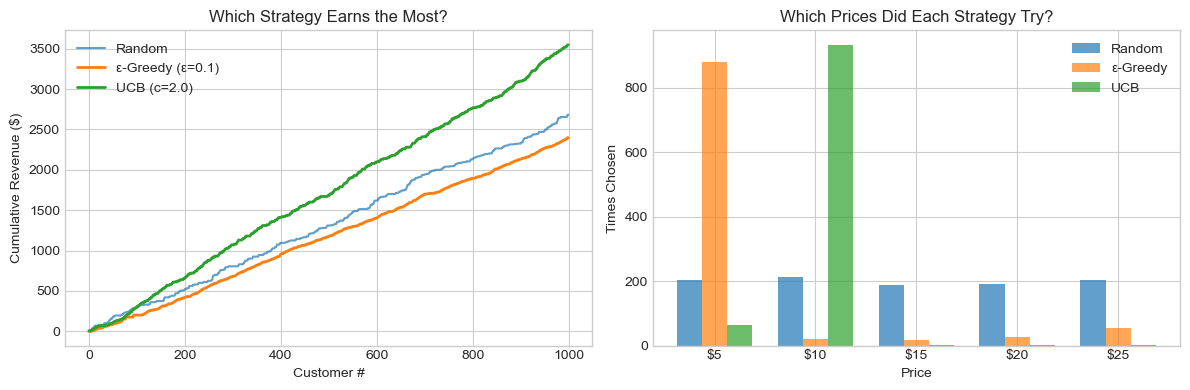

Final Revenue after 1000 customers:
  Random:    $2,685
  ε-Greedy:  $2,400
  UCB:       $3,550


In [8]:
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# ✈️ CHANGE THESE VALUES AND RE-RUN!
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
EPSILON = 0.1          # For ε-greedy. Try: 0, 0.05, 0.1, 0.2, 0.5
UCB_CONFIDENCE = 2.0   # For UCB. Try: 0.5, 1.0, 2.0, 5.0
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

N_CUSTOMERS = 1000

# Run three strategies
random_history, random_counts, _ = run_bandit('random', 0, N_CUSTOMERS)
eg_history, eg_counts, _ = run_bandit('epsilon-greedy', EPSILON, N_CUSTOMERS)
ucb_history, ucb_counts, _ = run_bandit('ucb', 0, N_CUSTOMERS, UCB_CONFIDENCE)

# Plot results
plt.figure(figsize=(12, 4))

# Left: Revenue over time
plt.subplot(1, 2, 1)
plt.plot(random_history, label='Random', alpha=0.7)
plt.plot(eg_history, label=f'ε-Greedy (ε={EPSILON})', linewidth=2)
plt.plot(ucb_history, label=f'UCB (c={UCB_CONFIDENCE})', linewidth=2)
plt.xlabel('Customer #')
plt.ylabel('Cumulative Revenue ($)')
plt.title('Which Strategy Earns the Most?')
plt.legend()

# Right: How often each price was chosen
plt.subplot(1, 2, 2)
x = np.arange(5)
width = 0.25
plt.bar(x - width, random_counts, width, label='Random', alpha=0.7)
plt.bar(x, eg_counts, width, label=f'ε-Greedy', alpha=0.7)
plt.bar(x + width, ucb_counts, width, label=f'UCB', alpha=0.7)
plt.xticks(x, ['$5', '$10', '$15', '$20', '$25'])
plt.xlabel('Price')
plt.ylabel('Times Chosen')
plt.title('Which Prices Did Each Strategy Try?')
plt.legend()

plt.tight_layout()
plt.show()

# Print final revenues
print(f"Final Revenue after {N_CUSTOMERS} customers:")
print(f"  Random:    ${random_history[-1]:,}")
print(f"  ε-Greedy:  ${eg_history[-1]:,}")
print(f"  UCB:       ${ucb_history[-1]:,}")

---

# Part 2: Q-Learning

Try changing the parameters:

- `LEARNING_RATE`: How fast the agent updates its beliefs (0 to 1)
- `DISCOUNT`: How much the agent values future vs immediate rewards (0 to 1)
- `EPSILON`: How often to explore (0 to 1)

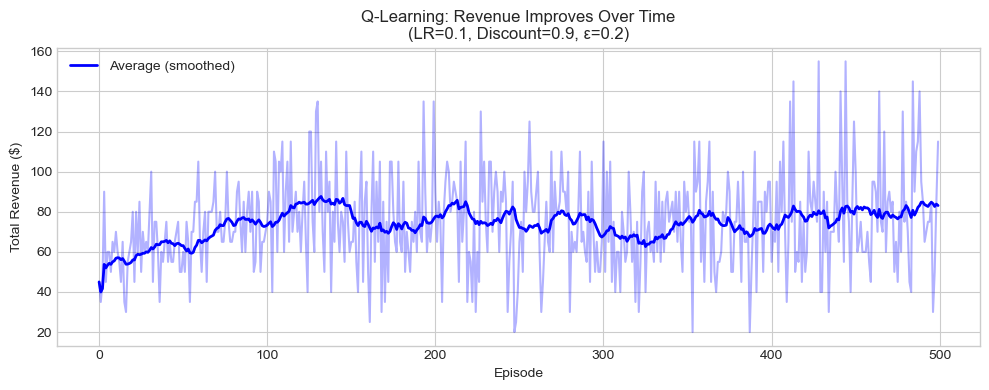

Average revenue (first 50 episodes):  $60.3
Average revenue (last 50 episodes):   $79.6


In [12]:
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# ✈️ CHANGE THESE VALUES AND RE-RUN!
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
LEARNING_RATE = 0.1   # Try: 0.01, 0.1, 0.5, 0.9
DISCOUNT = 0.9        # Try: 0, 0.5, 0.9, 0.99
EPSILON = 0.2         # Try: 0, 0.1, 0.2, 0.5
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

N_EPISODES = 500

# Train the agent
revenues, Q_table = run_qlearning(LEARNING_RATE, DISCOUNT, EPSILON, N_EPISODES)

# Plot learning curve
plt.figure(figsize=(10, 4))

# Smooth the curve
window = 20
smoothed = [np.mean(revenues[max(0,i-window):i+1]) for i in range(len(revenues))]

plt.plot(revenues, alpha=0.3, color='blue')
plt.plot(smoothed, color='blue', linewidth=2, label='Average (smoothed)')
plt.xlabel('Episode')
plt.ylabel('Total Revenue ($)')
plt.title(f'Q-Learning: Revenue Improves Over Time\n(LR={LEARNING_RATE}, Discount={DISCOUNT}, ε={EPSILON})')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average revenue (first 50 episodes):  ${np.mean(revenues[:50]):.1f}")
print(f"Average revenue (last 50 episodes):   ${np.mean(revenues[-50:]):.1f}")

---

## What Did the Agent Learn?

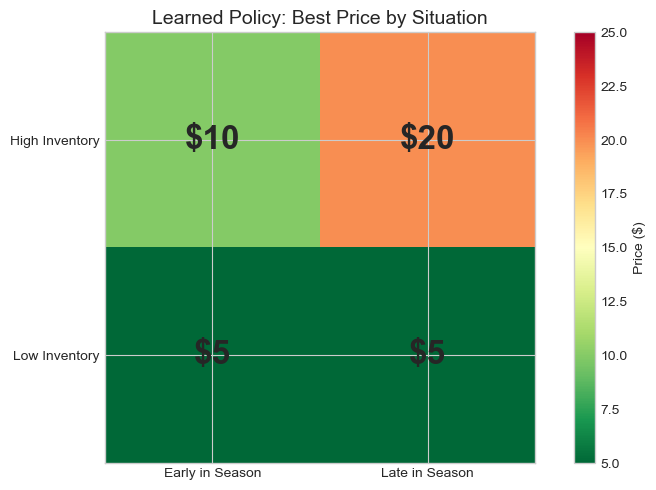

In [21]:
# Visualize as a simple table
fig, ax = plt.subplots(figsize=(8, 5))

# Build policy grid
policy_grid = []
for inv in ['high', 'low']:
    row = []
    for time in ['early', 'late']:
        best_action = Q_table[(inv, time)].index(max(Q_table[(inv, time)]))
        row.append(PRICES[best_action])
    policy_grid.append(row)

# Create heatmap
im = ax.imshow(policy_grid, cmap='RdYlGn_r', vmin=5, vmax=25)

# Labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Early in Season', 'Late in Season'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['High Inventory', 'Low Inventory'])

# Add price labels in cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'${policy_grid[i][j]}', ha='center', va='center', 
                fontsize=24, fontweight='bold')

plt.title('Learned Policy: Best Price by Situation', fontsize=14)
plt.colorbar(im, label='Price ($)')
plt.tight_layout()
plt.show()